In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
ROOT = Path('..').resolve()
REPORTS = ROOT / 'outputs' / 'reports'
FIGURES = ROOT / 'outputs' / 'figures' / 'prompt3'
FIGURES.mkdir(parents=True, exist_ok=True)
design = json.loads((REPORTS / 'prompt3_frozen_design.json').read_text())
environment = json.loads((REPORTS / 'prompt3_environment.json').read_text())
winners = json.loads((REPORTS / 'prompt3_family_winners.json').read_text())
anchor = json.loads((REPORTS / 'prompt3_deep_anchor.json').read_text())
bootstrap = json.loads((REPORTS / 'prompt3_paired_bootstrap.json').read_text())
runtime = json.loads((REPORTS / 'prompt3_runtime.json').read_text())
candidates = pd.read_csv(REPORTS / 'prompt3_candidate_results.csv')
leaderboard = pd.read_csv(REPORTS / 'prompt3_common_validation_leaderboard.csv')

Matplotlib is building the font cache; this may take a moment.


## Objective and scope

This stage compares two Deep tabular families on frozen Development Validation. It does not use Raw or IID data.

## Prompt 2 handoff

All required Prompt 2 reports passed before Deep work started.

In [2]:
display(pd.DataFrame([{'Prompt 2 ready': True, 'Raw access': 0, 'IID feature access': 0, 'IID target access': 0}]))

,Prompt 2 ready,Raw access,IID feature access,IID target access
0,True,0,0,0


## Development Train and Validation roles

Learned steps use 400,000 Train rows. Final Candidate metrics use the same 100,000 Validation rows.

In [3]:
display(pd.DataFrame([design['development_source']])[['development_rows','train_rows','validation_rows']])

,development_rows,train_rows,validation_rows
0,500000,400000,100000


## Deep feature contract

Both families use the exact 35-feature no-sensitive and no-lender contract.

In [4]:
display(pd.DataFrame({'feature': design['feature_contract']['features']}))

,feature
0,agency_name
1,loan_type_name
2,property_type_name
3,loan_purpose_name
4,owner_occupancy_name
5,preapproval_name
6,msamd_name
7,state_name
8,state_abbr
9,state_code


## Environment and device

The saved environment report records the packages and actual devices.

In [5]:
display(pd.DataFrame([environment['packages']]).T.rename(columns={0: 'version'})); display(pd.DataFrame([{'RealMLP': environment['realmlp_device'], 'FT': design['ft_device']}]))

,version
numpy,2.5.1
pandas,3.0.3
scikit-learn,1.9.0
torch,2.13.0
pytabkit,1.7.3
rtdl-revisiting-models,0.0.2
joblib,1.5.3
pyarrow,25.0.0


,RealMLP,FT
0,cpu float32,cpu


## Train-only preprocessing

Medians, quantiles, and category vocabularies are learned only from allowed Train roles.

In [6]:
display(pd.DataFrame([design['realmlp_execution_policy'], design['ft_preprocessing_policy']]))

,device,random_state,n_cv,n_refit,n_repeats,val_fraction,n_epochs,batch_size,predict_batch_size,n_threads,...,verbosity,num_workers_mapping,external_validation_passed_to_fit,numeric_preprocessing,categorical_preprocessing,numeric,n_quantiles,output_distribution,subsample,categorical_indices
0,cpu,42.0,1.0,1.0,1.0,0.1,30.0,1024.0,4096.0,4.0,...,1.0,not exposed; official in-process loader,False,Train-only median imputation,Train-only official encoder with stable missin...,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Train-only median then QuantileTransformer,1000.0,normal,NaN,"{'missing': 0, 'unknown': 1, 'known_start': 2}"


## RealMLP design

RealMLP uses a raw target, CPU float32, one internal split, and its official full-Train refit.

## RealMLP Candidate results

The two predeclared dropout settings are compared below.

In [7]:
display(candidates.loc[candidates.family.eq('realmlp'), ['candidate_id','mae','rmse','top_decile_mae','top_five_percent_mae','fit_time_seconds']])

,candidate_id,mae,rmse,top_decile_mae,top_five_percent_mae,fit_time_seconds
0,realmlp_raw_pdrop015,66.886234,126.881546,193.747815,271.397469,171.853618
1,realmlp_raw_pdrop020,66.367403,125.895709,191.958740,268.516404,177.555942


## Selected RealMLP

The selected family representative remains a Development model, not a final article model.

In [8]:
display(pd.DataFrame([winners['winners']['realmlp']])[['candidate_id','mae','rmse','top_decile_mae','top_five_percent_mae']])

,candidate_id,mae,rmse,top_decile_mae,top_five_percent_mae
0,realmlp_raw_pdrop020,66.367403,125.895709,191.95874,268.516404


## FT-Transformer design

Both FT Candidates use the same small architecture and differ only in weight decay.

## FT internal split

The fixed 360,000/40,000 split comes only from Development Train rows.

In [9]:
display(pd.DataFrame([design['ft_internal_split']]))

,random_state,stratification,fit_rows,early_stopping_rows,internal_overlap,external_validation_overlap,fit_row_hash_digest,early_stopping_row_hash_digest
0,42,duplicate-safe target deciles,360000,40000,0,0,531f00a3738cdb6619506cb92fc47e395747c4a71a69b2...,0ac72c3bfb85cd2fae34c9138f9b9f9ca343187e760e4e...


## FT Candidate results

Original-scale internal MAE selects the epoch; external Validation selects the Candidate.

In [10]:
display(candidates.loc[candidates.family.eq('fttransformer'), ['candidate_id','selected_epoch','mae','rmse','top_decile_mae','top_five_percent_mae']])

,candidate_id,selected_epoch,mae,rmse,top_decile_mae,top_five_percent_mae
2,fttransformer_log1p_wd1e5,21,65.454866,134.62839,202.687137,288.34644
3,fttransformer_log1p_wd1e4,21,65.454866,134.62839,202.687137,288.34644


## Selected FT-Transformer

The selected Candidate is refitted on all 400,000 Train rows for its frozen epoch.

In [11]:
display(pd.DataFrame([winners['winners']['fttransformer']])[['candidate_id','selected_epoch','mae','rmse','top_decile_mae','top_five_percent_mae']])

,candidate_id,selected_epoch,mae,rmse,top_decile_mae,top_five_percent_mae
0,fttransformer_log1p_wd1e5,21,65.809259,136.059498,215.719239,309.344671


## Training curves

Saved histories are displayed without training or preprocessing fitting.

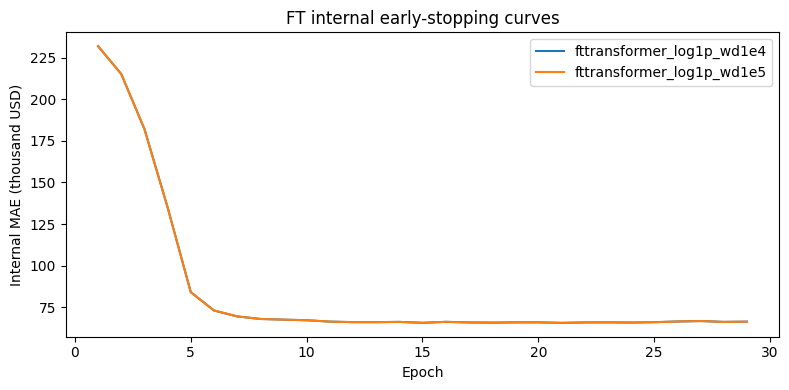

In [12]:
history_files = sorted((ROOT / 'outputs' / 'models' / 'prompt3' / 'candidates').glob('fttransformer_*/training_history.json'))
fig, ax = plt.subplots(figsize=(8, 4))
for path in history_files:
    rows = json.loads(path.read_text())['history']
    ax.plot([r['epoch'] for r in rows], [r['internal_original_scale_mae'] for r in rows], label=path.parent.name)
ax.set(xlabel='Epoch', ylabel='Internal MAE (thousand USD)', title='FT internal early-stopping curves')
ax.legend(); fig.tight_layout(); fig.savefig(FIGURES / 'ft_training_curves.png', dpi=150); plt.show()

## Deep-family comparison

RealMLP and FT use exactly aligned Validation rows.

,family,mae,rmse,r2,rmsle
4,fttransformer,65.809259,136.059498,0.641343,0.402438
5,realmlp,66.367403,125.895709,0.692926,0.464621


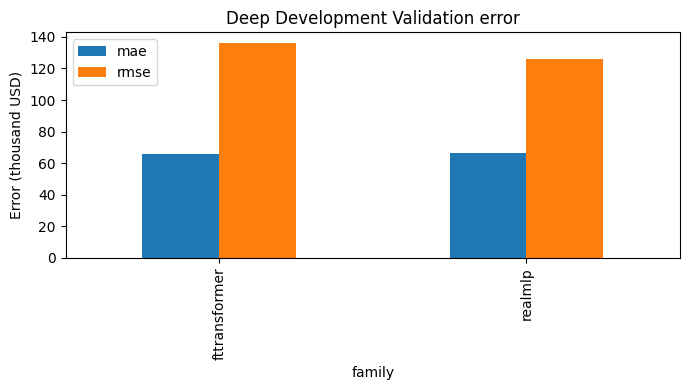

In [13]:
deep = leaderboard.loc[leaderboard.stage.eq('Prompt 3')]
display(deep[['family','mae','rmse','r2','rmsle']])
ax = deep.set_index('family')[['mae','rmse']].plot.bar(figsize=(7,4), title='Deep Development Validation error')
ax.set_ylabel('Error (thousand USD)'); plt.tight_layout(); plt.savefig(FIGURES / 'deep_mae_rmse.png', dpi=150); plt.show()

## Paired bootstrap

The paired bootstrap is descriptive Development evidence, not an independent Test result.

In [14]:
display(pd.DataFrame([bootstrap]))

,status,created_at_utc,n_rows,n_resamples,random_state,realmlp_minus_ft_mae_difference,percentile_2_5,median,percentile_97_5,realmlp_win_proportion,ft_win_proportion,tie_proportion,scope
0,PASS,2026-08-06T11:15:56.349342+00:00,100000,300,42,0.558143,0.262376,0.577666,0.841211,0.0,1.0,0.0,"Descriptive Development Validation evidence, n..."


## Common Boosting/Deep Validation leaderboard

Saved Prompt 2 predictions and saved Prompt 3 predictions form one aligned table.

In [15]:
display(leaderboard[['stage','family','model_id','mae','rmse','top_decile_mae','top_five_percent_mae']])

,stage,family,model_id,mae,rmse,top_decile_mae,top_five_percent_mae
0,Prompt 2,catboost,cat_raw_mae__3e13a9b27727,62.660954,126.795248,194.785914,279.640881
1,Prompt 2,xgboost,xgb_log1p_l2_anchor__311ad287a6aa,63.243238,126.088854,202.854094,286.992072
2,Prompt 2,lightgbm,lgb_raw_l1__64ec65b8e75e,63.296230,125.698421,195.460670,280.182225
3,Prompt 2,histgradientboosting,hgb_log1p_l1__b71d4c769e8e,64.137294,129.547701,199.631925,287.125002
4,Prompt 3,fttransformer,fttransformer_log1p_wd1e5,65.809259,136.059498,215.719239,309.344671
5,Prompt 3,realmlp,realmlp_raw_pdrop020,66.367403,125.895709,191.958740,268.516404
6,Prompt 2,lasso,lasso_log1p_anchor__8c42e8499ad0,70.348448,137.513190,228.340719,325.416109


## Tail-error comparison

Tail metrics use the original loan-amount scale and Validation target quantiles.

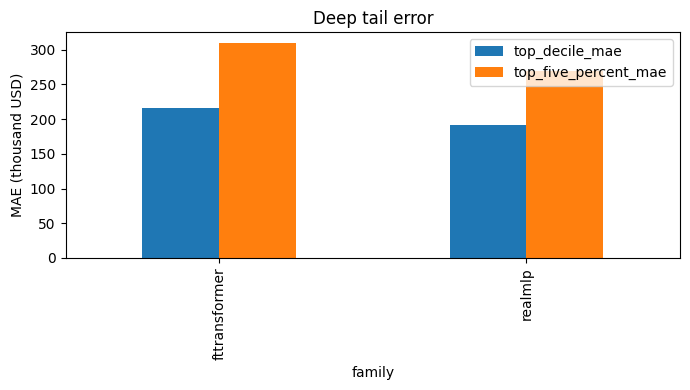

In [16]:
ax = deep.set_index('family')[['top_decile_mae','top_five_percent_mae']].plot.bar(figsize=(7,4), title='Deep tail error')
ax.set_ylabel('MAE (thousand USD)'); plt.tight_layout(); plt.savefig(FIGURES / 'deep_tail_mae.png', dpi=150); plt.show()

## Signed-error comparison

Negative signed error means underprediction. The chart includes a zero line.

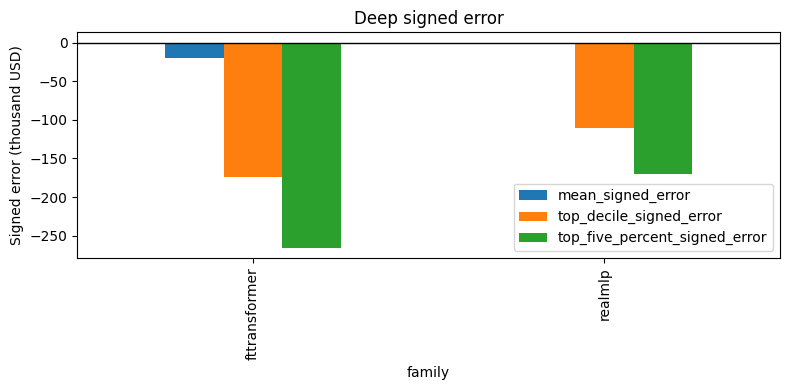

In [17]:
ax = deep.set_index('family')[['mean_signed_error','top_decile_signed_error','top_five_percent_signed_error']].plot.bar(figsize=(8,4), title='Deep signed error')
ax.axhline(0, color='black', linewidth=1); ax.set_ylabel('Signed error (thousand USD)'); plt.tight_layout(); plt.savefig(FIGURES / 'deep_signed_error.png', dpi=150); plt.show()

## Runtime and model-size comparison

Runtime and storage are technical evidence, not selection evidence beyond frozen tie rules.

In [18]:
display(deep[['family','fit_time_seconds','prediction_time_seconds','model_size_bytes','bundle_size_bytes']])

,family,fit_time_seconds,prediction_time_seconds,model_size_bytes,bundle_size_bytes
4,fttransformer,5831.235617,12.783150,6638637,6822171
5,realmlp,177.555942,0.778802,2892947,2906259


## Saved bundles and predictions

Both complete family bundles and both aligned prediction files are preserved.

In [19]:
display(pd.DataFrame([{'family': k, 'bundle': v['selected_bundle_path'], 'predictions': v['selected_prediction_path']} for k,v in winners['winners'].items()]))

,family,bundle,predictions
0,realmlp,outputs/models/prompt3/selected_realmlp,outputs/predictions/prompt3/validation/selecte...
1,fttransformer,outputs/models/prompt3/selected_fttransformer,outputs/predictions/prompt3/validation/selecte...


## Verification

Final verification checks access closure, fit counts, reload, alignment, and notebook behavior.

In [20]:
verification_path = REPORTS / 'prompt3_verification.json'
display(pd.DataFrame([json.loads(verification_path.read_text())]) if verification_path.exists() else pd.DataFrame([{'status': 'Verification runs after notebook execution'}]))

,status
0,Verification runs after notebook execution


## Limitations

Development Validation is not a new independent holdout. GPU was used only if the saved smoke proved it.

## Prompt 4 handoff

Prompt 4 may compare frozen families and build later systems only after a genuine Prompt 3 PASS.